# 04 - Modele ML: Linear Regression si Random Forest

Scop: prezicem `arr_delay` folosind Spark MLlib. Comparam Linear Regression cu Random Forest Regression folosind RMSE, MAE si R2.

Codul este KISS si foloseste doar biblioteci disponibile in Dockerfile.


In [1]:
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import IntegerType, DoubleType

spark = (
    SparkSession.builder
    .appName("FlightsProject")
    .master("spark://master:7077")
    .config("spark.executor.memory", "1g")
    .config("spark.executor.cores", "1")
    .config("spark.cores.max", "2")
    .config("spark.sql.shuffle.partitions", "4")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)
print("Master:", spark.sparkContext.master)


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 11:12:24 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.8
Master: spark://master:7077


In [2]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.regression import LinearRegression, RandomForestRegressor
from pyspark.ml.evaluation import RegressionEvaluator


## Incarcare date curatate


In [3]:
HDFS_CLEAN_CSV = "hdfs://master:9000/flights/clean"

df = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(HDFS_CLEAN_CSV)
    .repartition(4)
)

# Selectam doar coloane utile pentru model.
model_df = df.select(
    "arr_delay", "dep_delay", "air_time", "distance", "hour", "month", "carrier", "origin", "dest"
).dropna()

# Esantion optional pentru laptop slab. Daca merge repede, comentati linia sample.
model_df = model_df.sample(False, 0.35, seed=42)
model_df = model_df.cache()

print("Randuri pentru ML:", model_df.count())
model_df.select(
    "arr_delay", "dep_delay", "air_time",
    "distance", "hour", "month",
    "carrier", "origin", "dest"
).limit(10).toPandas()


Randuri pentru ML: 114514


,arr_delay,dep_delay,air_time,distance,hour,month,carrier,origin,dest
0,15.0,9.0,233.0,1416,18,11,UA,LGA,IAH
1,-24.0,-6.0,142.0,1023,18,2,UA,EWR,PBI
2,8.0,-1.0,47.0,187,13,10,B6,JFK,BOS
3,53.0,69.0,150.0,1020,10,3,DL,LGA,MSP
4,35.0,32.0,127.0,944,7,5,B6,JFK,MCO
5,-14.0,-3.0,341.0,2454,10,4,UA,EWR,LAX
6,-17.0,0.0,326.0,2454,19,9,UA,EWR,LAX
7,81.0,59.0,245.0,1521,17,1,AA,JFK,AUS
8,55.0,31.0,42.0,187,21,7,B6,JFK,BOS
9,-12.0,-12.0,101.0,569,17,10,9E,EWR,CVG


## Train-test split


In [4]:
train_df, test_df = model_df.randomSplit([0.8, 0.2], seed=42)
print("Train:", train_df.count())
print("Test:", test_df.count())


Train: 91792
Test: 22722


## Pipeline de feature engineering

Categoricele sunt transformate cu StringIndexer + OneHotEncoder. Numericele sunt puse direct in vectorul de features.


In [5]:
categorical_cols = ["carrier", "origin", "dest"]
numeric_cols = ["dep_delay", "air_time", "distance", "hour", "month"]

indexers = [
    StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep")
    for c in categorical_cols
]
encoders = [
    OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe")
    for c in categorical_cols
]

assembler = VectorAssembler(
    inputCols=numeric_cols + [f"{c}_ohe" for c in categorical_cols],
    outputCol="features",
    handleInvalid="keep"
)


## Model 1: Linear Regression


In [6]:
lr = LinearRegression(
    featuresCol="features",
    labelCol="arr_delay",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0.0
)

lr_pipeline = Pipeline(stages=indexers + encoders + [assembler, lr])
lr_model = lr_pipeline.fit(train_df)
lr_pred = lr_model.transform(test_df).cache()
lr_pred.select(
    "arr_delay", "prediction", "dep_delay",
    "carrier", "origin", "dest"
).limit(10).toPandas()

26/04/27 11:13:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/04/27 11:13:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
26/04/27 11:13:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
                                                                                

,arr_delay,prediction,dep_delay,carrier,origin,dest
0,-69.0,-27.729453,-1.0,UA,EWR,LAS
1,-66.0,-34.504261,0.0,UA,EWR,SFO
2,-65.0,-43.989815,-2.0,UA,EWR,SNA
3,-63.0,-38.825280,-4.0,UA,EWR,SFO
4,-62.0,-26.574071,-1.0,DL,JFK,LAX
5,-60.0,-35.072983,-5.0,UA,EWR,LAX
6,-57.0,-52.312949,-10.0,UA,JFK,LAX
7,-56.0,-29.522243,-9.0,EV,EWR,MSY
8,-55.0,-22.692397,-5.0,DL,JFK,SLC
9,-55.0,-37.897236,3.0,AA,JFK,LAX


## Model 2: Random Forest Regression

Parametrii sunt mici ca sa ruleze pe laptop slab.


In [7]:
rf = RandomForestRegressor(
    featuresCol="features",
    labelCol="arr_delay",
    numTrees=25,
    maxDepth=6,
    seed=42
)

rf_pipeline = Pipeline(stages=indexers + encoders + [assembler, rf])
rf_model = rf_pipeline.fit(train_df)
rf_pred = rf_model.transform(test_df).cache()
rf_pred.select(
    "arr_delay", "prediction", "dep_delay",
    "carrier", "origin", "dest"
).limit(10).toPandas()

,arr_delay,prediction,dep_delay,carrier,origin,dest
0,-69.0,-6.043507,-1.0,UA,EWR,LAS
1,-66.0,-8.808610,0.0,UA,EWR,SFO
2,-65.0,-6.673862,-2.0,UA,EWR,SNA
3,-63.0,-12.108131,-4.0,UA,EWR,SFO
4,-62.0,-7.502247,-1.0,DL,JFK,LAX
5,-60.0,-11.539717,-5.0,UA,EWR,LAX
6,-57.0,-11.558558,-10.0,UA,JFK,LAX
7,-56.0,-7.324785,-9.0,EV,EWR,MSY
8,-55.0,-9.899592,-5.0,DL,JFK,SLC
9,-55.0,-6.566498,3.0,AA,JFK,LAX


## Metrici: RMSE, MAE, R2


In [8]:
def regression_metrics(pred_df, model_name):
    evaluators = {
        "RMSE": RegressionEvaluator(labelCol="arr_delay", predictionCol="prediction", metricName="rmse"),
        "MAE": RegressionEvaluator(labelCol="arr_delay", predictionCol="prediction", metricName="mae"),
        "R2": RegressionEvaluator(labelCol="arr_delay", predictionCol="prediction", metricName="r2"),
    }
    rows = []
    for metric_name, evaluator in evaluators.items():
        rows.append((model_name, metric_name, float(evaluator.evaluate(pred_df))))
    return rows

metrics_rows = regression_metrics(lr_pred, "Linear Regression") + regression_metrics(rf_pred, "Random Forest")
metrics_df = spark.createDataFrame(metrics_rows, ["model", "metric", "value"])
metrics_df.toPandas()

,model,metric,value
0,Linear Regression,RMSE,15.139096
1,Linear Regression,MAE,10.593227
2,Linear Regression,R2,0.882027
3,Random Forest,RMSE,23.755423
4,Random Forest,MAE,15.296743
5,Random Forest,R2,0.709525


Interpretare: RMSE si MAE mai mici inseamna predictii mai bune. R2 mai aproape de 1 inseamna ca modelul explica mai bine variatia intarzierii la sosire. `dep_delay` este de obicei cea mai importanta variabila, deoarece intarzierea la plecare influenteaza direct intarzierea la sosire.


## Comparatie vizuala a metricilor


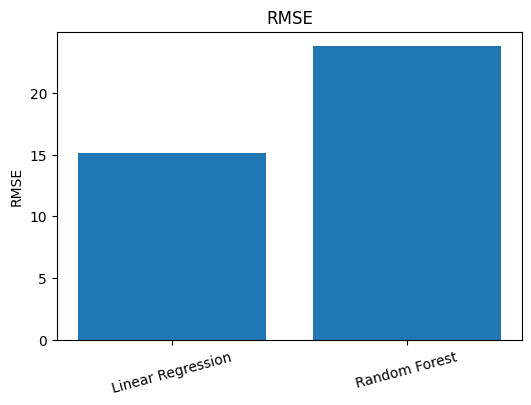

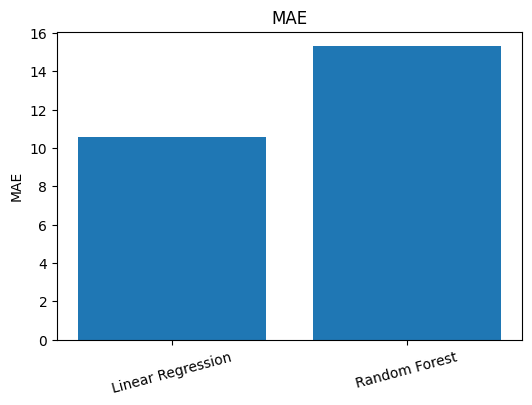

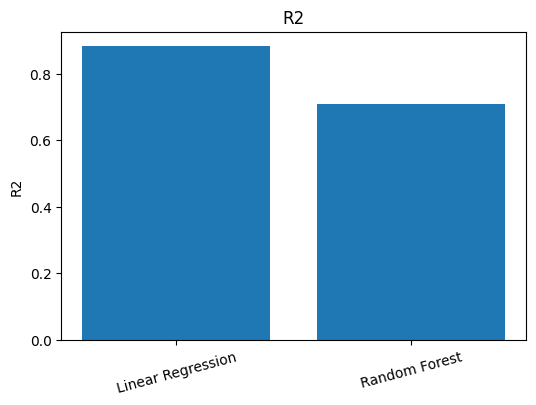

In [9]:
import matplotlib.pyplot as plt

pdf_metrics = metrics_df.toPandas()
for metric in ["RMSE", "MAE", "R2"]:
    part = pdf_metrics[pdf_metrics["metric"] == metric]
    plt.figure(figsize=(6, 4))
    plt.bar(part["model"], part["value"])
    plt.title(metric)
    plt.ylabel(metric)
    plt.xticks(rotation=15)
    plt.show()


## Salvare predictii sample

Salvam un sample mic CSV in HDFS pentru demonstratie. Nu salvam Parquet.


In [10]:
OUTPUT_PRED = "hdfs://master:9000/flights/output/rf_predictions_sample_csv"

rf_pred.select("arr_delay", "prediction", "dep_delay", "air_time", "distance", "carrier", "origin", "dest") \
    .limit(1000) \
    .coalesce(1) \
    .write.mode("overwrite") \
    .option("header", True) \
    .csv(OUTPUT_PRED)

print("Saved predictions sample to:", OUTPUT_PRED)


[Stage 107:>                                                        (0 + 1) / 1]

Saved predictions sample to: hdfs://master:9000/flights/output/rf_predictions_sample_csv


In [11]:
pred_sample = (
    spark.read
    .option("header", True)
    .option("inferSchema", True)
    .csv(OUTPUT_PRED)
)

print("Randuri salvate:", pred_sample.count())

pred_sample.limit(20).toPandas()

Randuri salvate: 1000


,arr_delay,prediction,dep_delay,air_time,distance,carrier,origin,dest
0,-69.0,-6.043507,-1.0,276.0,2227,UA,EWR,LAS
1,-66.0,-8.808610,0.0,306.0,2565,UA,EWR,SFO
2,-65.0,-6.673862,-2.0,291.0,2434,UA,EWR,SNA
3,-63.0,-12.108131,-4.0,307.0,2565,UA,EWR,SFO
4,-62.0,-7.502247,-1.0,306.0,2475,DL,JFK,LAX
5,-60.0,-11.539717,-5.0,294.0,2454,UA,EWR,LAX
6,-57.0,-11.558558,-10.0,280.0,2475,UA,JFK,LAX
7,-56.0,-7.324785,-9.0,146.0,1167,EV,EWR,MSY
8,-55.0,-9.899592,-5.0,264.0,1990,DL,JFK,SLC
9,-55.0,-6.566498,3.0,282.0,2475,AA,JFK,LAX


26/04/27 15:06:40 WARN HeartbeatReceiver: Removing executor 1 with no recent heartbeats: 2062993 ms exceeds timeout 120000 ms
26/04/27 15:06:41 ERROR TaskSchedulerImpl: Lost executor 1 on 10.4.4.9: Executor heartbeat timed out after 2062993 ms
26/04/27 15:06:41 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_177_0 !
26/04/27 15:06:41 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_105_2 !
26/04/27 15:06:41 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_18_0 !
26/04/27 15:06:41 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_105_0 !
26/04/27 15:06:41 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_18_2 !
26/04/27 15:06:41 WARN BlockManagerMasterEndpoint: No more replicas available for rdd_177_2 !


## Concluzie ML

Am antrenat doua modele de regresie pe Spark MLlib. Linear Regression este simplu si interpretabil. Random Forest poate captura relatii neliniare, dar consuma mai multe resurse. Comparatia finala se face prin RMSE, MAE si R2.
